# Foulplay Resale Market Analysis
### What the secondary market reveals about demand for Foulplay pieces

**Data:** 736 sold listings from Grailed (Sep 2021 – Jun 2026)

---

This notebook analyzes every Foulplay listing sold on Grailed that the platform's
search index still returns. The goal is not to study resale economics for its own
sake, but to use resale data as a **demand signal**: Which designs does the market
chase hard enough to suggest a re-drop?

The analysis lands on two connected findings:

1. **Price stability**: Foulplay's resale value has held steady around a \$45 median
   for five years. This flat baseline is what makes the second finding meaningful.
2. **Outlier pieces**: A small set of pieces break dramatically from that baseline,
   selling for multiples of their category norm. 

**Scope & honesty notes**
- This is *Grailed* sold data only, so one resale channel, not the full secondary market.
- `sold_price` is a real clearing price. The `original_price` field is the *seller's
  listing/ask price*, **not** Foulplay's retail price, so this data cannot measure true
  retail-to-resale premium (though it could be calculated...).
- A handful of listings are unrelated brands ("Foreplay"/"ForPlay") caught by fuzzy
  search; these are filtered out below.


## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

df = pd.read_csv('foulplay_clean.csv', parse_dates=['sold_at', 'created_at'])
print(f"Loaded {len(df)} sold listings")
df.head()

Loaded 736 sold listings


,id,title,designer,garment_type,item_type,size_value,condition_label,condition_rank,color,ask_price,sold_price,sold_vs_ask,sold_vs_ask_pct,currency,sold_at,created_at,days_to_sell,sold_year,sold_month,url
0,93918986,foulplay,Foulplay Company,tops,short_sleeve_shirts,xxl,New,5,black,50,50,0,0.0,USD,2026-05-12 04:51:19.616000+00:00,2026-03-16 02:07:19.782000+00:00,57,2026,2026-05,https://www.grailed.com/listings/93918986
1,71633763,foulplay,"Foulplay Company, Fuck The Population, G59 Rec...",accessories,hats,one_size,Gently used,4,black,44,44,0,0.0,USD,2025-01-26 20:27:50.611000+00:00,2024-12-07 08:36:28.529000+00:00,50,2025,2025-01,https://www.grailed.com/listings/71633763
2,39351987,Foulplay,Foulplay Company,tops,short_sleeve_shirts,l,New,5,white,20,27,7,35.0,USD,2023-02-24 15:46:03.783000+00:00,2023-01-11 11:08:37.433000+00:00,44,2023,2023-02,https://www.grailed.com/listings/39351987
3,95262854,Foulplay Central Bookings Collab Sniper Shirt,Foulplay Company,tops,short_sleeve_shirts,xl,New,5,black,49,40,-9,-18.4,USD,2026-06-20 23:35:49.672000+00:00,2026-04-12 09:29:46.162000+00:00,69,2026,2026-06,https://www.grailed.com/listings/95262854
4,94672961,Foulplay “gun” tee,Foulplay Company,tops,short_sleeve_shirts,l,Used,3,black,20,15,-5,-25.0,USD,2026-06-18 20:33:59.676000+00:00,2026-03-30 19:38:34.291000+00:00,80,2026,2026-06,https://www.grailed.com/listings/94672961


### Filter out non-Foulplay matches

Grailed's search caught a few listings for unrelated brands with similar names
(*Foreplay*, *ForPlay*). We remove them so every statistic reflects Foulplay only.
Eyeballing the data rather than trusting the search blindly is what keeps the
numbers defensible.

In [2]:
before = len(df)
mask_bad = df['title'].str.contains('foreplay|forplay', case=False, na=False)
df = df[~mask_bad].copy()
print(f"Removed {mask_bad.sum()} non-Foulplay listings — {before} -> {len(df)} remain")

Removed 4 non-Foulplay listings — 736 -> 732 remain


## 2. The price landscape

First, what does Foulplay actually clear at on the secondary market?

In [3]:
summary = df['sold_price'].describe()[['min','25%','50%','75%','max']]
print("Sold price (USD):")
for k, v in summary.items():
    print(f"  {k:>4}: ${v:,.0f}")
print(f"\nMedian piece sells for ${df['sold_price'].median():.0f}; "
      f"most fall between ${df['sold_price'].quantile(.25):.0f} and "
      f"${df['sold_price'].quantile(.75):.0f}.")

Sold price (USD):
   min: $1
   25%: $30
   50%: $45
   75%: $70
   max: $959

Median piece sells for $45; most fall between $30 and $70.


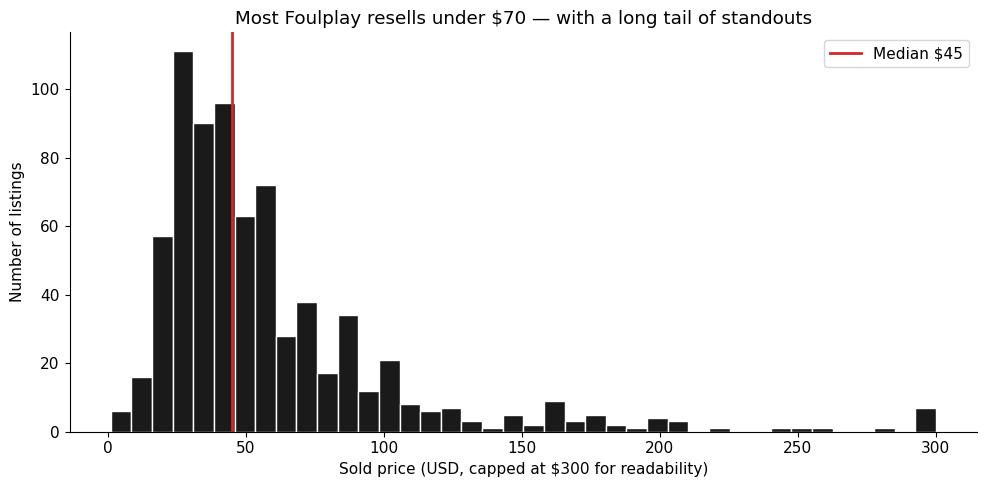

In [4]:
fig, ax = plt.subplots()
ax.hist(df['sold_price'].clip(upper=300), bins=40, color='#1a1a1a', edgecolor='white')
ax.axvline(df['sold_price'].median(), color='#d62728', lw=2,
           label=f"Median ${df['sold_price'].median():.0f}")
ax.set_xlabel('Sold price (USD, capped at $300 for readability)')
ax.set_ylabel('Number of listings')
ax.set_title('Most Foulplay resells under $70 — with a long tail of standouts')
ax.legend()
plt.tight_layout(); plt.show()

**NOTE:** Foulplay is, on the whole, an accessible sub-\$70 brand on resale. The
story isn't the typical piece, it's the long right tail which we will investigate later on.

## 3. Finding 1 — The market is stable

A natural hypothesis is that as the brand grew, resale prices climbed. The data does
**not** support that. Median sold price has been essentially flat for five years.

In [5]:
by_year = df.groupby(df['sold_at'].dt.year)['sold_price'].agg(['count','median']).round(0)
by_year.columns = ['listings_sold', 'median_price']
by_year

,listings_sold,median_price
sold_at,,
2021,62,45.0
2022,185,45.0
2023,188,45.0
2024,153,45.0
2025,121,48.0
2026,23,50.0


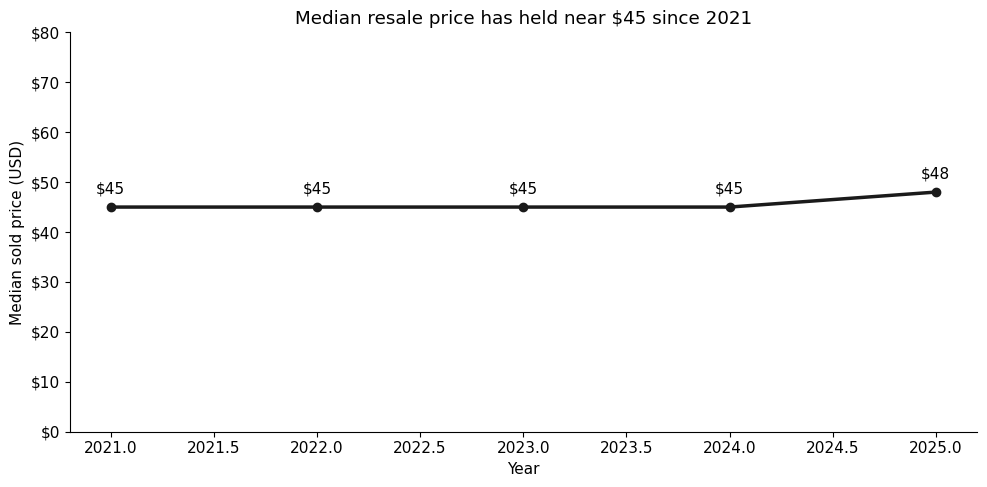

In [6]:
fig, ax = plt.subplots()
yr = by_year[by_year.index < 2026]  # 2026 is a partial year; exclude from trend
ax.plot(yr.index, yr['median_price'], marker='o', lw=2.5, color='#1a1a1a')
ax.set_ylim(0, 80)
ax.set_ylabel('Median sold price (USD)')
ax.set_xlabel('Year')
ax.set_title('Median resale price has held near $45 since 2021')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
for x, y in zip(yr.index, yr['median_price']):
    ax.annotate(f'${y:.0f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
plt.tight_layout(); plt.show()

**NOTE:** Stability isn't a flashy headline on its own, but it's the essential
backdrop. Because the baseline is flat and predictable, any piece that breaks far
above it is a real signal rather than noise. *(2026 excluded from
the trend line since only a partial year of data.)*

## 4. Where value concentrates by category

Before isolating individual outliers, we look at which categories carry value.
We report **both median and mean** on purpose: the gap between them is itself the story.

In [7]:
cat = (df.groupby('garment_type')['sold_price']
         .agg(['count','median','mean']).round(1))
cat = cat[cat['count'] >= 5].sort_values('median', ascending=False)
cat

,count,median,mean
garment_type,,,
outerwear,40,100.0,126.2
bottoms,47,49.0,56.3
tops,488,45.0,53.4
accessories,156,44.0,70.1


Notice **accessories**: a low median (~\$44) but a much higher mean (~\$70). That
gap means most accessories are cheap hats, but the category hides a few extreme
outliers dragging the average up, which is exactly where Foulplay's grail pieces live.
Outerwear, by contrast, is consistently valuable (high median). Reporting only the mean
would have hidden this; reporting both reveals the real shape.

## 5. Finding 2 — The outlier pieces (the centerpiece)

Here is the part a brand owner can act on. Within each garment type we flag pieces
selling far above the category norm, using two complementary methods that should agree
if the signal is real:

- **`x_median`** — how many times the category median a piece sold for (intuitive)
- **`z`** — a log-price z-score within garment type (statistically robust to skew)

We also keep **condition** in view: if a high price came from a pristine example, that's
less interesting than a *worn* piece still commanding a premium — the latter is pure
demand for the design.

In [8]:
# robust within-category outlier scores
df['log_price'] = np.log(df['sold_price'].clip(lower=1))
df['z'] = (df.groupby('garment_type')['log_price']
             .transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else 0)
             .round(2))
cat_median = df.groupby('garment_type')['sold_price'].transform('median')
df['x_median'] = (df['sold_price'] / cat_median).round(1)

top = (df.sort_values('x_median', ascending=False)
         [['title','garment_type','condition_label','sold_price','x_median','z']]
         .head(15).reset_index(drop=True))
top

,title,garment_type,condition_label,sold_price,x_median,z
0,FOUPLAY YOU’RE BEING ROBBED HAT,accessories,Used,959,21.8,3.77
1,you're being robbed day hat,accessories,Gently used,559,12.7,3.09
2,Foulplay your being robbed dad hat,accessories,Used,512,11.6,2.98
3,TeamSesh X Foulplay Collab Hoodie (RARE),tops,Used,380,8.4,3.72
4,you're being robbed day hat,accessories,Gently used,300,6.8,2.30
5,Black & white FTP cartel tee,tops,New,260,5.8,3.06
6,Foulplay Arch Logo Chain,accessories,New,220,5.0,1.91
7,Foulplay “You’re Being Robbed” Rug,accessories,Gently used,200,4.5,1.79
8,College Micro Pendant,accessories,Gently used,200,4.5,1.79
9,Run for your life work jacket,outerwear,New,445,4.4,2.25


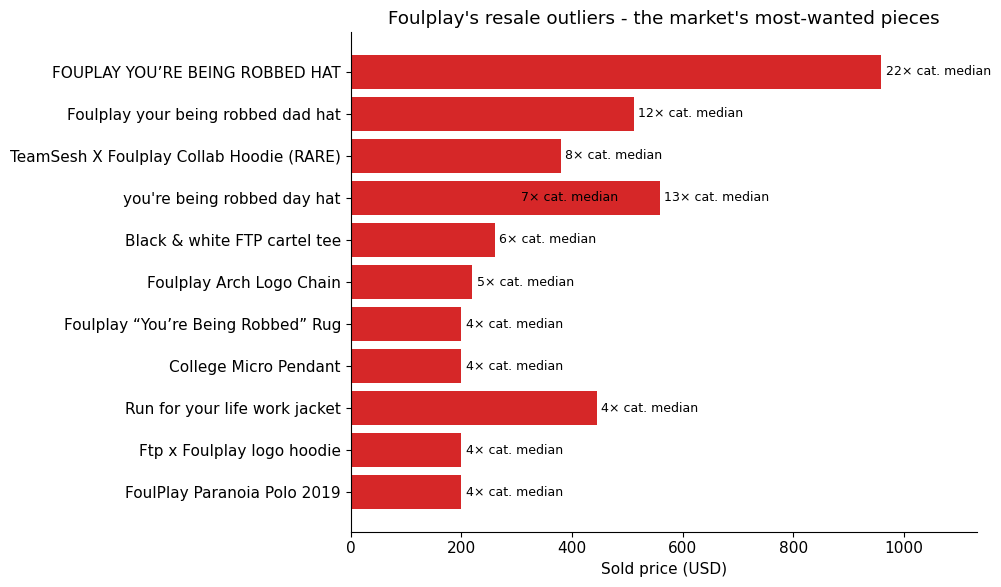

In [9]:
# Visualize the top outliers
t = top.head(12).iloc[::-1]
labels = [f"{ti[:40]}{'…' if len(ti) > 40 else ''}" for ti in t['title']]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels, t['sold_price'], color='#d62728')
ax.set_xlabel('Sold price (USD)')
ax.set_title("Foulplay's resale outliers - the market's most-wanted pieces")
for b, x in zip(bars, t['x_median']):
    ax.text(b.get_width() + 8, b.get_y() + b.get_height()/2,
            f'{x:.0f}× cat. median', va='center', fontsize=9)
ax.margins(x=0.18)
plt.tight_layout(); plt.show()

### What the outliers say

**1. The "You're Being Robbed" design is Foulplay's resale crown jewel.**
The hat sold for roughly **22× the typical accessory price**, and the design recurs
across hats and even a rug, all commanding large premiums. A concept that
appears *repeatedly* at the top of an outlier list is the strongest possible re-drop
signal: the market has said, with money, over and over, that it wants this.

**2. Collabs systematically over-perform.**
TeamSesh, FTP (Fuck The Population), Cultgloria, and G59-adjacent pieces cluster near
the top. Collaboration pieces hold premium resale value years later, an argument for
treating collabs as flagship drops.

**3. The premiums are real demand, not condition.**
The top "You're Being Robbed" hats sold in **Used / Gently used** condition. They
command top dollar *despite* wear, which means the price reflects desire for the design
itself, not the freshness of the item.

In [10]:
# How many pieces qualify as outliers?
print(f"Pieces selling >= 2x their category median: {(df['x_median'] >= 2).sum()}")
print(f"Pieces selling >= 3x their category median: {(df['x_median'] >= 3).sum()}")
print("\nThese form a curated shortlist of re-drop candidates.")

Pieces selling >= 2x their category median: 104
Pieces selling >= 3x their category median: 37

These form a curated shortlist of re-drop candidates.


## 6. Quantifying the collab premium

The outlier list suggested collabs over-perform. Let's check that directly by flagging
titles that mention known collaborators and comparing their sold prices to everything else.

In [11]:
collab_terms = ['ftp', 'fuck the population', 'teamsesh', 'team sesh', 'g59',
                'cultgloria', 'suicide', 'collab', 'x ']
df['is_collab'] = df['title'].str.lower().str.contains('|'.join(collab_terms), na=False)

comp = df.groupby('is_collab')['sold_price'].agg(['count','median','mean']).round(1)
comp.index = ['Solo pieces', 'Collab pieces']
print(comp)
lift = comp.loc['Collab pieces','median'] / comp.loc['Solo pieces','median']
print(f"\nCollab pieces carry roughly a {lift:.1f}x median price premium over solo pieces.")

               count  median  mean
Solo pieces      603    44.0  57.8
Collab pieces    129    60.0  76.7

Collab pieces carry roughly a 1.4x median price premium over solo pieces.


*Caveat:* this is a keyword heuristic, so it will miss collabs that don't name the
partner in the title.

## 7. What this suggests

Reading the resale market as a demand signal, three things stand out for product decisions:

- **Re-drop the "You're Being Robbed" line.** It is the clearest, most durable demand
  signal in the entire dataset, outperforming every hoodie and jacket, even in used
  condition, and recurring across multiple product forms.
- **Lean into collaborations.** They generate resale value that persists well beyond the
  launch window, which argues for positioning them as premium, intentionally scarce drops.
- **The everyday line is healthy and stable.** A flat ~\$45 baseline across five years is
  a sign of consistent, durable brand demand, the steady floor beneath the standout pieces.

**Where this could go next (with first-party data):** Foulplay's own Shopify and
Instagram data would unlock what resale data cannot. True retail-to-resale premium,
buyer-location mapping for pop-up planning, size-curve production planning, and
content-to-sales attribution. This resale analysis is the publicly reachable first layer.
